In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('dynamic_data.csv')

In [ ]:
df.shape

(62000, 66)

In [ ]:
df.head()

,sequence_id,frame_num,x1,y1,z1,x2,y2,z2,x3,y3,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0,0,0.0,0.0,0.0,-0.264161,-0.170797,-0.099798,-0.463315,-0.475247,...,0.220853,-1.148543,-0.283732,0.229536,-1.360376,-0.314927,0.225315,-1.560548,-0.336449,HELLO
1,0,1,0.0,0.0,0.0,-0.263941,-0.170441,-0.097618,-0.456104,-0.474812,...,0.226182,-1.139817,-0.279277,0.233919,-1.348914,-0.316012,0.225133,-1.549809,-0.341676,HELLO
2,0,2,0.0,0.0,0.0,-0.269101,-0.157246,-0.108779,-0.472159,-0.463709,...,0.222731,-1.154919,-0.284898,0.232240,-1.363638,-0.322047,0.227404,-1.564464,-0.348338,HELLO
3,0,3,0.0,0.0,0.0,-0.264080,-0.164478,-0.108832,-0.458395,-0.470191,...,0.228931,-1.142706,-0.283658,0.237455,-1.351456,-0.315557,0.232058,-1.550452,-0.336843,HELLO
4,0,4,0.0,0.0,0.0,-0.263421,-0.163782,-0.106069,-0.458570,-0.467046,...,0.230868,-1.144019,-0.286876,0.240319,-1.352518,-0.319747,0.235155,-1.551537,-0.342288,HELLO


In [ ]:
sequences=[]
labels=[]

In [ ]:
feature_cols=[c for c in df.columns
              if c not in ['sequence_id','frame_num','label']]

In [ ]:
for seq_id in df['sequence_id'].unique():
  seq=df[df['sequence_id']==seq_id].sort_values('frame_num')
  sequences.append(seq[feature_cols].values)
  labels.append(seq['label'].values[0])

In [ ]:
X=np.array(sequences)
y=np.array(labels)

In [ ]:
X.shape

(3100, 20, 63)

In [ ]:
y.shape

(3100,)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
y_encoded=le.fit_transform(y)
n_classes=len(le.classes_)

In [ ]:
n_classes

31

In [ ]:
le.classes_

array(['BAD', 'CANCEL', 'COME', 'DRINK', 'EAT', 'FOOD', 'GO', 'GOOD',
       'HAPPY', 'HELLO', 'HELP', 'HOME', 'ME', 'NEXT', 'NO', 'OK',
       'PLEASE', 'PREVIOUS', 'SAD', 'SELECT', 'SLEEP', 'SORRY', 'START',
       'STOP', 'THANKS', 'TIME', 'WAIT', 'WATER', 'WORK', 'YES', 'YOU'],
      dtype='<U8')

In [ ]:
import pickle

In [ ]:
# with open("label_encoder.pkl","wb") as f:
  # pickle.dump(le,f)

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
x_train,x_val,y_train,y_val=train_test_split(X,y_encoded,test_size=0.33,random_state=42,stratify=y_encoded)

In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
model_lstm = models.Sequential([
    layers.LSTM(128, return_sequences=True,
                input_shape=(20,63)),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])


In [ ]:
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         2,015 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,887 (601.12 KB)

 Trainable params: 153,887 (601.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_lstm=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_lstm]
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.2826 - loss: 2.5529 - val_accuracy: 0.7283 - val_loss: 1.3535
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6245 - loss: 1.2263 - val_accuracy: 0.7761 - val_loss: 0.6658
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7448 - loss: 0.8021 - val_accuracy: 0.8847 - val_loss: 0.4131
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8007 - loss: 0.6085 - val_accuracy: 0.8935 - val_loss: 0.3533
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8252 - loss: 0.5513 - val_accuracy: 0.8407 - val_loss: 0.3904
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8459 - loss: 0.4701 - val_accuracy: 0.9150 - val_loss: 0.2305
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8806 - loss: 0.3870 - val_accuracy: 0.9335 - val_loss: 0.2042
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8739 - loss: 0.4200 - val_accuracy: 0.8641 - v

In [ ]:
model_cnn = models.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(20, 63)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

In [ ]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop_cnn=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history_cnn = model_cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_cnn]
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5460 - loss: 1.7130 - val_accuracy: 0.7507 - val_loss: 2.2147
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8262 - loss: 0.6246 - val_accuracy: 0.8680 - val_loss: 1.2204
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8922 - loss: 0.3748 - val_accuracy: 0.8798 - val_loss: 0.6230
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9124 - loss: 0.2956 - val_accuracy: 0.8671 - val_loss: 0.3990
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9326 - loss: 0.2150 - val_accuracy: 0.9374 - val_loss: 0.2430
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9456 - loss: 0.1821 - val_accuracy: 0.9668 - val_loss: 0.1232
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9576 - loss: 0.1495 - val_accuracy: 0.9501 - val_loss: 0.1569
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9547 - loss: 0.1539 - val_accuracy: 0.9677 - val_loss

In [ ]:
model_gru = models.Sequential([
    layers.GRU(128, return_sequences=True, input_shape=(20, 63), dropout=0.3),
    layers.GRU(64, return_sequences=False, dropout=0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

In [ ]:
model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [ ]:
early_stop_gru=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history_gru=model_gru.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_gru]
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.2003 - loss: 2.8452 - val_accuracy: 0.5376 - val_loss: 1.8358
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4401 - loss: 1.7996 - val_accuracy: 0.7410 - val_loss: 1.0047
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5725 - loss: 1.2878 - val_accuracy: 0.7977 - val_loss: 0.7220
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6529 - loss: 1.0369 - val_accuracy: 0.8045 - val_loss: 0.5467
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6740 - loss: 0.9301 - val_accuracy: 0.8465 - val_loss: 0.4616
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7188 - loss: 0.8002 - val_accuracy: 0.8622 - val_loss: 0.4203
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7390 - loss: 0.7424 - val_accuracy: 0.8524 - val_loss: 0.4149
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7415 - loss: 0.7433 - val_accuracy: 0.8631 - v

In [ ]:
import pandas as pd
import time

def get_results(history, model_name,model):
    best_val_loss = min(history.history['val_loss'])
    best_epoch = history.history['val_loss'].index(best_val_loss) + 1
    best_val_acc = max(history.history['val_accuracy'])
    model_params= model.count_params()
    start = time.time()
    model.predict(x_val[:1])
    model_time = time.time() - start

    return {
        "Model": model_name,
        "Best Val Accuracy": best_val_acc,
        "Best Val Loss": best_val_loss,
        "Best Epoch": best_epoch,
        "model param": model_params,
        "Inference Time": model_time
    }

results = [
    get_results(history, "LSTM",model_lstm),
    get_results(history_cnn, "1D CNN",model_cnn),
    get_results(history_gru, "GRU",model_gru)
]

df = pd.DataFrame(results)
print(df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
    Model  Best Val Accuracy  Best Val Loss  Best Epoch  model param  \
0    LSTM           0.982405       0.086215          24       153887   
1  1D CNN           0.979472       0.071571          12        47903   
2     GRU           0.978495       0.098156          47       117535   

   Inference Time  
0        0.082229  
1        0.070559  
2        0.074817  


The LSTM model achieved the highest validation accuracy (98.24%), demonstrating strong capability in modeling temporal dependencies in gesture sequences. The 1D CNN model achieved the lowest validation loss and required significantly fewer parameters, making it the most computationally efficient architecture. The GRU model also performed competitively but required more training epochs to converge. Overall, all models achieved over 97% validation accuracy, indicating robust gesture classification performance.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


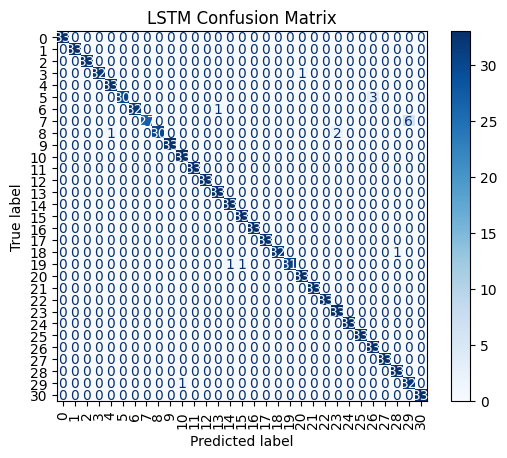

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


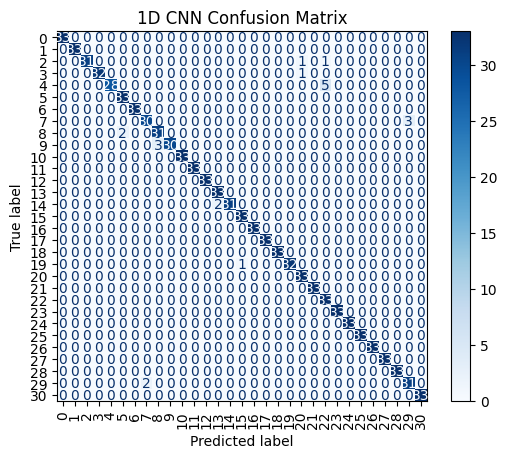

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


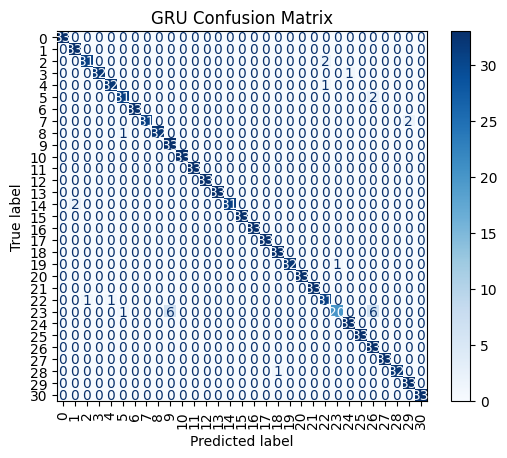

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_confusion_matrix(model, name):

    y_pred = model.predict(x_val)
    y_pred_classes = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_val, y_pred_classes)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", xticks_rotation=90)

    plt.title(f"{name} Confusion Matrix")
    plt.show()


get_confusion_matrix(model_lstm, "LSTM")
get_confusion_matrix(model_cnn, "1D CNN")
get_confusion_matrix(model_gru, "GRU")

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history, model_name):

    plt.figure(figsize=(12,5))

    # Loss curve
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{model_name} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy curve
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{model_name} Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

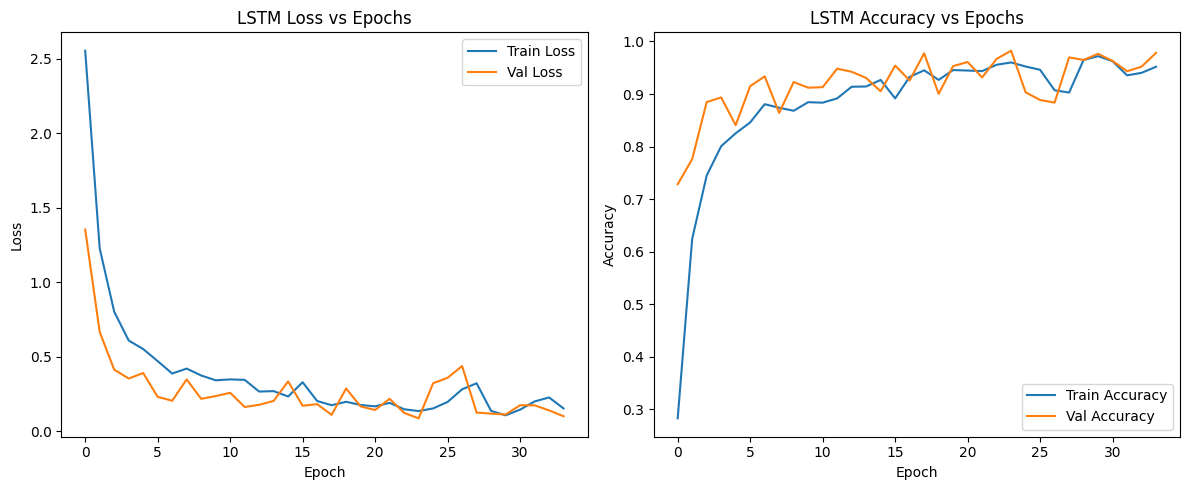

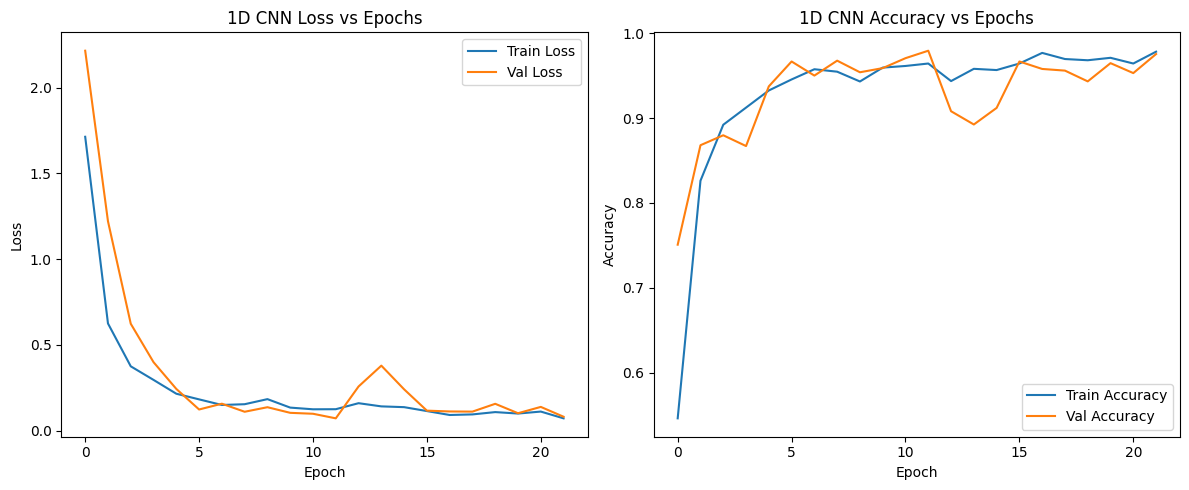

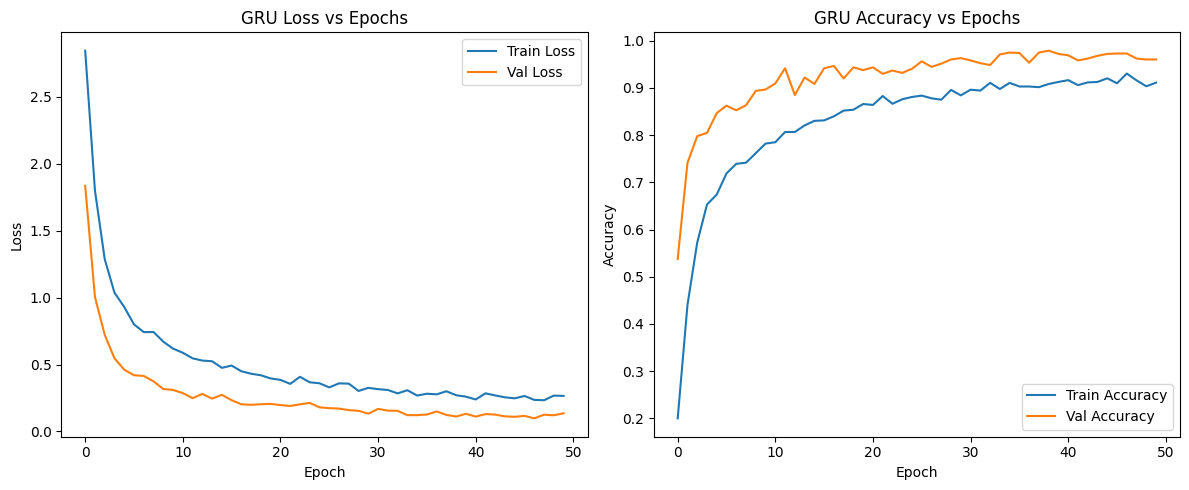

In [ ]:
plot_training_curves(history, "LSTM")
plot_training_curves(history_cnn, "1D CNN")
plot_training_curves(history_gru, "GRU")

#insight
The CNN model converges significantly faster than the recurrent architectures, achieving stable loss within the first 10 epochs. The LSTM model demonstrates strong temporal learning capability and achieves the highest validation accuracy. The GRU model converges more slowly but maintains stable performance across epochs. Overall, all three architectures achieve validation accuracy above 97%, indicating strong classification performance.

#FINAL STATEMENT
The LSTM model achieved the highest validation accuracy (98.24%), indicating strong temporal learning capability.
However, the 1D CNN achieved comparable performance while using significantly fewer parameters and faster inference time.

Therefore, CNN provides a better trade-off between accuracy and computational efficiency for this gesture classification task.

In [ ]:
model_cnn.save("model_cnn.keras")
model_lstm.save("model_lstm.keras")
model_gru.save("model_gru.keras")